In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
data=pd.read_csv("Rajasthan_Heatwave.csv")
data.head()

,YEAR,MONTH,DAY,WIND_U10,WIND_V10,MSLP,BLH,GEOP,TEMP2M,TMAX,...,RAIN,SRAD,EVAP,SOILT1,SOILM1,LAI,HEATWAVE,LAT,LON,DISTRICT
0,2006,3,1,-0.223022,-0.440903,101036.375,2020.7317,1671.1079,304.75806,303.54395,...,0.0,3117056,-0.000023,312.75903,0.024887,0.515625,0,25.75,71.5,Barmer
1,2006,3,2,-1.344009,-0.294922,101076.440,2265.7910,1671.1079,306.45337,304.95703,...,0.0,3131200,-0.000024,312.66943,0.024345,0.515625,0,25.75,71.5,Barmer
2,2006,3,3,-0.960449,1.522965,101033.750,3152.6023,1671.1079,307.34863,306.21167,...,0.0,3105536,-0.000024,313.12280,0.023773,0.515625,0,25.75,71.5,Barmer
3,2006,3,4,2.704514,1.733017,100896.940,3146.9475,1671.1079,307.43457,306.70508,...,0.0,3126528,-0.000024,314.12085,0.023147,0.515625,0,25.75,71.5,Barmer
4,2006,3,5,2.717834,2.464432,101014.190,2069.5261,1671.1079,306.19507,304.88306,...,0.0,2776448,-0.000041,312.00806,0.027964,0.515625,0,25.75,71.5,Barmer


In [3]:
label_encoder=LabelEncoder()
data["DISTRICT"]=label_encoder.fit_transform(data["DISTRICT"])

In [4]:
data.head()

,YEAR,MONTH,DAY,WIND_U10,WIND_V10,MSLP,BLH,GEOP,TEMP2M,TMAX,...,RAIN,SRAD,EVAP,SOILT1,SOILM1,LAI,HEATWAVE,LAT,LON,DISTRICT
0,2006,3,1,-0.223022,-0.440903,101036.375,2020.7317,1671.1079,304.75806,303.54395,...,0.0,3117056,-0.000023,312.75903,0.024887,0.515625,0,25.75,71.5,0
1,2006,3,2,-1.344009,-0.294922,101076.440,2265.7910,1671.1079,306.45337,304.95703,...,0.0,3131200,-0.000024,312.66943,0.024345,0.515625,0,25.75,71.5,0
2,2006,3,3,-0.960449,1.522965,101033.750,3152.6023,1671.1079,307.34863,306.21167,...,0.0,3105536,-0.000024,313.12280,0.023773,0.515625,0,25.75,71.5,0
3,2006,3,4,2.704514,1.733017,100896.940,3146.9475,1671.1079,307.43457,306.70508,...,0.0,3126528,-0.000024,314.12085,0.023147,0.515625,0,25.75,71.5,0
4,2006,3,5,2.717834,2.464432,101014.190,2069.5261,1671.1079,306.19507,304.88306,...,0.0,2776448,-0.000041,312.00806,0.027964,0.515625,0,25.75,71.5,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21960 entries, 0 to 21959
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   YEAR      21960 non-null  int64  
 1   MONTH     21960 non-null  int64  
 2   DAY       21960 non-null  int64  
 3   WIND_U10  21960 non-null  float64
 4   WIND_V10  21960 non-null  float64
 5   MSLP      21960 non-null  float64
 6   BLH       21960 non-null  float64
 7   GEOP      21960 non-null  float64
 8   TEMP2M    21960 non-null  float64
 9   TMAX      21960 non-null  float64
 10  TMIN      21960 non-null  float64
 11  DEW2M     21960 non-null  float64
 12  CLOUD     21960 non-null  float64
 13  RAIN      21960 non-null  float64
 14  SRAD      21960 non-null  int64  
 15  EVAP      21960 non-null  float64
 16  SOILT1    21960 non-null  float64
 17  SOILM1    21960 non-null  float64
 18  LAI       21960 non-null  float64
 19  HEATWAVE  21960 non-null  int64  
 20  LAT       21960 non-null  fl

In [6]:
#data["DATE"]=pd.to_datetime(data[['YEAR','MONTH','DAY']])

In [7]:
#data.head()

In [8]:
data.columns

Index(['YEAR', 'MONTH', 'DAY', 'WIND_U10', 'WIND_V10', 'MSLP', 'BLH', 'GEOP',
       'TEMP2M', 'TMAX', 'TMIN', 'DEW2M', 'CLOUD', 'RAIN', 'SRAD', 'EVAP',
       'SOILT1', 'SOILM1', 'LAI', 'HEATWAVE', 'LAT', 'LON', 'DISTRICT'],
      dtype='object')

In [9]:
df=data.copy()
df=df.drop(["YEAR","MONTH","DAY","TMAX","TMIN","LAT","LON","DISTRICT"],axis=1)
df.head()

,WIND_U10,WIND_V10,MSLP,BLH,GEOP,TEMP2M,DEW2M,CLOUD,RAIN,SRAD,EVAP,SOILT1,SOILM1,LAI,HEATWAVE
0,-0.223022,-0.440903,101036.375,2020.7317,1671.1079,304.75806,271.71143,0.000000,0.0,3117056,-0.000023,312.75903,0.024887,0.515625,0
1,-1.344009,-0.294922,101076.440,2265.7910,1671.1079,306.45337,270.74316,0.000000,0.0,3131200,-0.000024,312.66943,0.024345,0.515625,0
2,-0.960449,1.522965,101033.750,3152.6023,1671.1079,307.34863,274.26490,0.000000,0.0,3105536,-0.000024,313.12280,0.023773,0.515625,0
3,2.704514,1.733017,100896.940,3146.9475,1671.1079,307.43457,272.11353,0.000000,0.0,3126528,-0.000024,314.12085,0.023147,0.515625,0
4,2.717834,2.464432,101014.190,2069.5261,1671.1079,306.19507,273.35303,0.917175,0.0,2776448,-0.000041,312.00806,0.027964,0.515625,0


In [10]:
X=df.drop(["HEATWAVE"],axis=1)
y=df["HEATWAVE"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((17568, 14), (4392, 14), (17568,), (4392,))

***Logistic Regression***

In [11]:
## Logistic Regression
logistic_regressor=LogisticRegression(max_iter=1000)
logistic_regressor.fit(X_train,y_train)
logistic_regressor_predict=logistic_regressor.predict(X_test)


In [12]:
from sklearn.metrics import accuracy_score,confusion_matrix,roc_curve,auc,precision_score,recall_score,f1_score

In [13]:
logistic_regressor_accuracy=accuracy_score(y_test,logistic_regressor_predict)
logistic_regressor_precision=precision_score(y_test,logistic_regressor_predict)
logistic_regressor_recall=recall_score(y_test,logistic_regressor_predict)
logistic_regressor_f1=f1_score(y_test,logistic_regressor_predict)
print(f'Accuracy Score of Logistic Regression is:{logistic_regressor_accuracy:.2f}')
print(f'Precision score of logistic regression s:{logistic_regressor_precision:.2f}')
print(f'Recall score of Logistic Regression is:{logistic_regressor_recall:.2f}')
print(f'f1 score of Logistic Regressor is:{logistic_regressor_f1:.2f}')

Accuracy Score of Logistic Regression is:0.98
Precision score of logistic regression s:0.82
Recall score of Logistic Regression is:0.75
f1 score of Logistic Regressor is:0.78


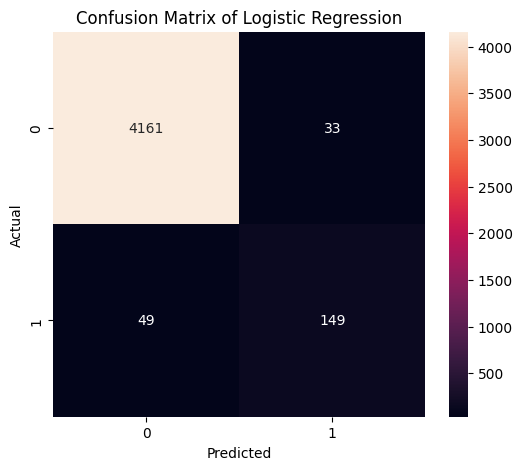

In [14]:
logistic_regressor_cm=confusion_matrix(y_test,logistic_regressor_predict)
plt.figure(figsize=(6,5))
sns.heatmap(logistic_regressor_cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Logistic Regression')
plt.show()

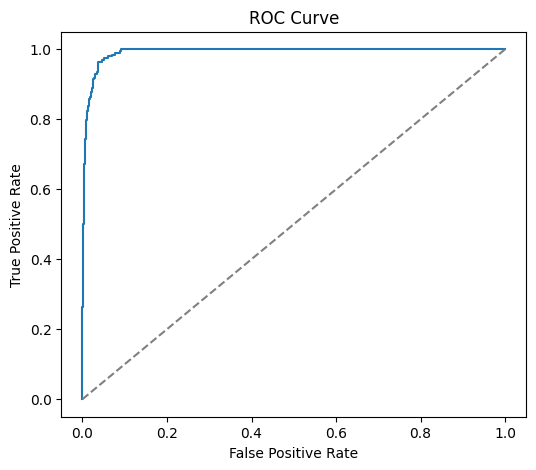

In [15]:
y_score=logistic_regressor.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_score)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f'AUC={roc_auc:.2f}')
plt.plot([0,1],[0,1],linestyle='--',color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC Curve')
plt.show()

***Decision Tree Regressor***

In [16]:
DT_classifier=DecisionTreeClassifier(max_depth=10)
DT_classifier.fit(X_train,y_train)
DT_predict=DT_classifier.predict(X_test)
DT_predict


array([0, 0, 0, ..., 0, 0, 0], shape=(4392,))

In [17]:
DT_accuracy=accuracy_score(y_test,DT_predict)
DT_precision=precision_score(y_test,DT_predict)
DT_recall=recall_score(y_test,DT_predict)
DT_f1=f1_score(y_test,DT_predict)
print(f'Accuracy Score of Decision Tree classifier is:{DT_accuracy:.2f}')
print(f'Precision score of Decision Tree classifier is:{DT_precision:.2f}')
print(f'Recall score of Decision Tree classifier is:{DT_recall:.2f}')
print(f'f1 score of Decision Tree classifier is:{DT_f1:.2f}')

Accuracy Score of Decision Tree classifier is:0.98
Precision score of Decision Tree classifier is:0.77
Recall score of Decision Tree classifier is:0.78
f1 score of Decision Tree classifier is:0.77


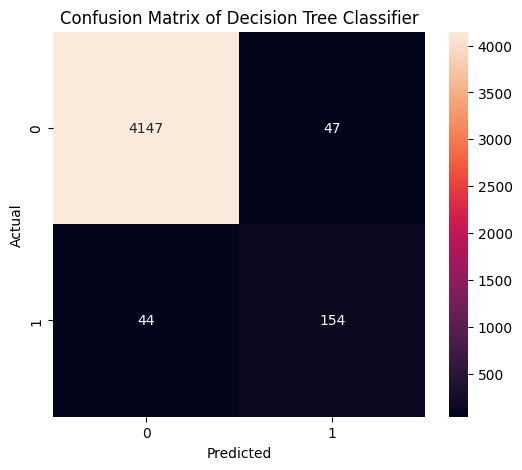

In [18]:
DT_cm=confusion_matrix(y_test,DT_predict)
plt.figure(figsize=(6,5))
sns.heatmap(DT_cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Decision Tree Classifier')
plt.show()

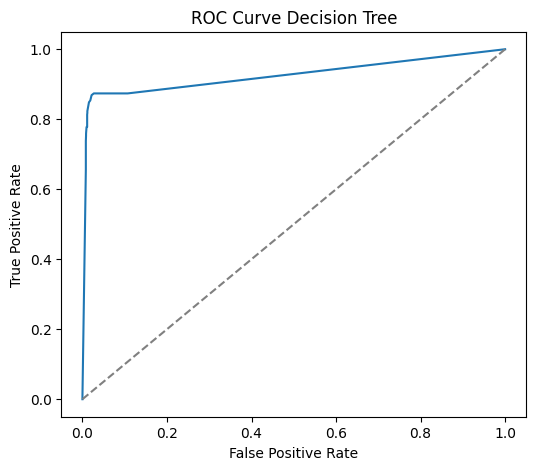

In [19]:
y_score_DT=DT_classifier.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_score_DT)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f'AUC={roc_auc:.2f}')
plt.plot([0,1],[0,1],linestyle='--',color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC Curve Decision Tree')
plt.show()

***Random Forest Classifier***

In [20]:
RF_classifier=RandomForestClassifier(max_depth=10)
RF_classifier.fit(X_train,y_train)
RF_predict=RF_classifier.predict(X_test)


In [21]:
RF_accuracy=accuracy_score(y_test,RF_predict)
RF_precision=precision_score(y_test,RF_predict)
RF_recall=recall_score(y_test,RF_predict)
RF_f1=f1_score(y_test,RF_predict)
print(f'Accuracy Score of Random Forest classifier is:{RF_accuracy:.2f}')
print(f'Precision score of Random Forest Classifier is:{RF_precision:.2f}')
print(f'Recall score of Random Forest Classifier is:{RF_recall:.2f}')
print(f'f1 score of Random Forest Classifier is:{RF_f1:.2f}')

Accuracy Score of Random Forest classifier is:0.99
Precision score of Random Forest Classifier is:0.88
Recall score of Random Forest Classifier is:0.81
f1 score of Random Forest Classifier is:0.84


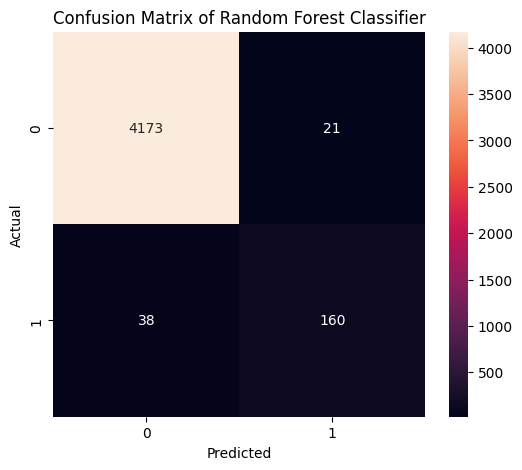

In [22]:
RF_cm=confusion_matrix(y_test,RF_predict)
plt.figure(figsize=(6,5))
sns.heatmap(RF_cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Random Forest Classifier')
plt.show()

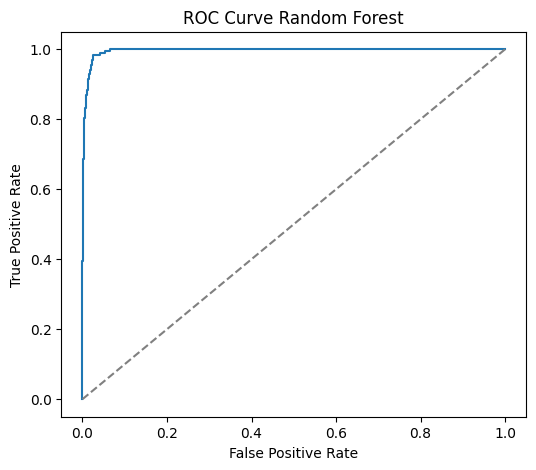

In [23]:
y_score_RF=RF_classifier.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_score_RF)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f'AUC={roc_auc:.2f}')
plt.plot([0,1],[0,1],linestyle='--',color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC Curve Random Forest')
plt.show()

***XGBoost Classifier***

In [24]:
from xgboost import XGBClassifier

In [25]:
xgb_classifier=XGBClassifier(n_estimators=100,learning_rate=0.1)
xgb_classifier.fit(X_train,y_train)
xgb_predict=xgb_classifier.predict(X_test)

In [26]:
xgb_accuracy=accuracy_score(y_test,xgb_predict)
xgb_precision=precision_score(y_test,xgb_predict)
xgb_recall=recall_score(y_test,xgb_predict)
xgb_f1=f1_score(y_test,xgb_predict)
print(f'Accuracy Score of XGBoost classifier is:{xgb_accuracy:.2f}')
print(f'Precision score of XGBoost Classifier is:{xgb_precision:.2f}')
print(f'Recall score of XGBoost Classifier is:{xgb_recall:.2f}')
print(f'f1 score of XGBoost Classifier is:{xgb_f1:.2f}')

Accuracy Score of XGBoost classifier is:0.99
Precision score of XGBoost Classifier is:0.85
Recall score of XGBoost Classifier is:0.83
f1 score of XGBoost Classifier is:0.84


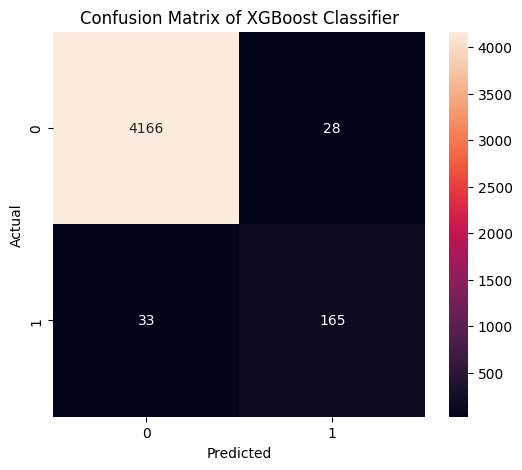

In [27]:
xgb_cm=confusion_matrix(y_test,xgb_predict)
plt.figure(figsize=(6,5))
sns.heatmap(xgb_cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of XGBoost Classifier')
plt.show()

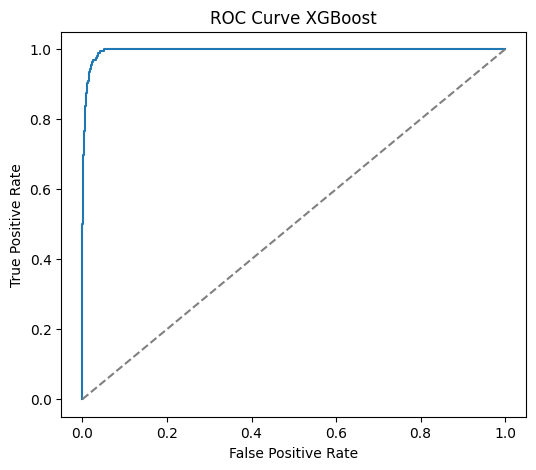

In [28]:
y_score_XGB=xgb_classifier.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_score_XGB)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f'AUC={roc_auc:.2f}')
plt.plot([0,1],[0,1],linestyle='--',color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC Curve XGBoost')
plt.show()

In [29]:
from sklearn.neighbors import KNeighborsClassifier


In [30]:
KN_classifier=KNeighborsClassifier()
KN_classifier.fit(X_train,y_train)
KN_predict=KN_classifier.predict(X_test)

In [31]:
KN_accuracy=accuracy_score(y_test,KN_predict)
KN_precision=precision_score(y_test,KN_predict)
KN_recall=recall_score(y_test,KN_predict)
KN_f1=f1_score(y_test,KN_predict)
print(f'Accuracy Score of KNeighbor classifier is:{KN_accuracy:.2f}')
print(f'Precision score of KNeighbor Classifier is:{KN_precision:.2f}')
print(f'Recall score of KNeighbor Classifier is:{KN_recall:.2f}')
print(f'f1 score of KNeighbor Classifier is:{KN_f1:.2f}')

Accuracy Score of KNeighbor classifier is:0.95
Precision score of KNeighbor Classifier is:0.33
Recall score of KNeighbor Classifier is:0.05
f1 score of KNeighbor Classifier is:0.09


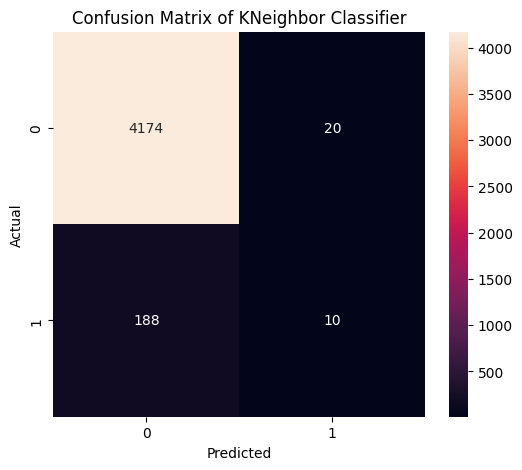

In [32]:
KN_cm=confusion_matrix(y_test,KN_predict)
plt.figure(figsize=(6,5))
sns.heatmap(KN_cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of KNeighbor Classifier')
plt.show()

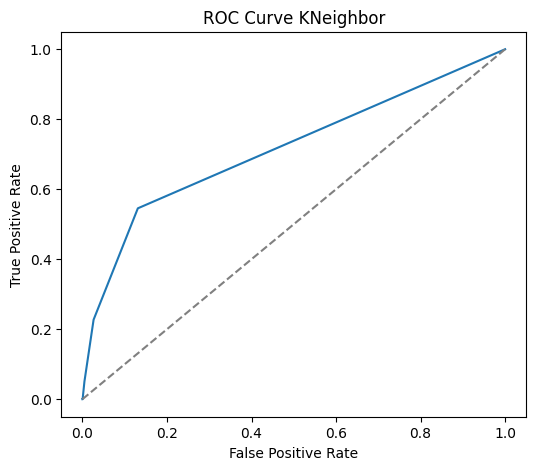

In [33]:
y_score_KN=KN_classifier.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_score_KN)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f'AUC={roc_auc:.2f}')
plt.plot([0,1],[0,1],linestyle='--',color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC Curve KNeighbor')
plt.show()

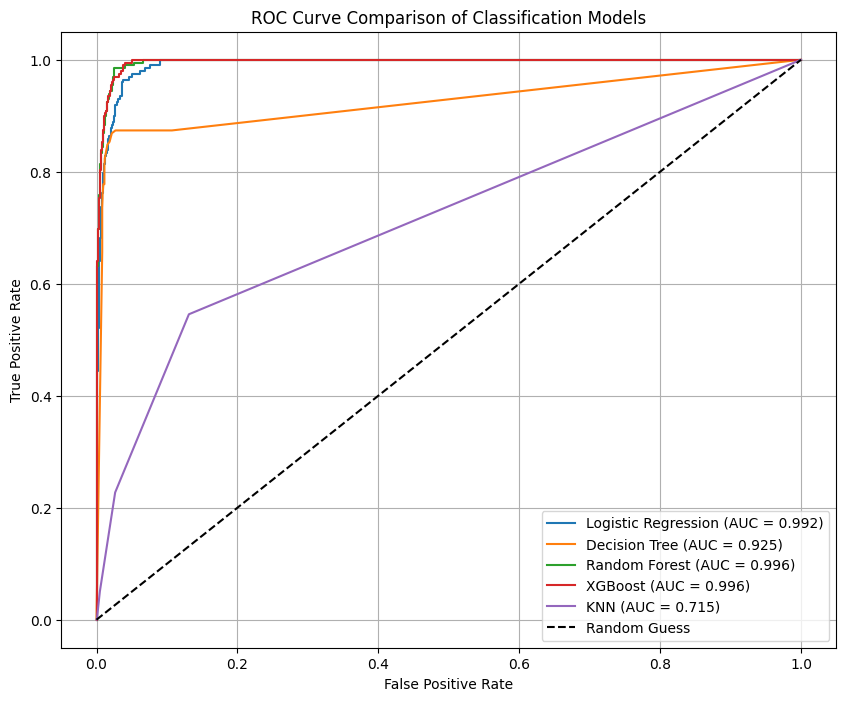

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, logistic_regressor.predict_proba(X_test)[:, 1])
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, DT_classifier.predict_proba(X_test)[:, 1])
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt,
         label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, RF_classifier.predict_proba(X_test)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_classifier.predict_proba(X_test)[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, KN_classifier.predict_proba(X_test)[:, 1])
roc_auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn,
         label=f'KNN (AUC = {roc_auc_knn:.3f})')

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Classification Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [35]:
from sklearn.metrics import roc_auc_score
auc_scores = {
    'Model': ['Logistic Regression', 'Decision Tree',
              'Random Forest', 'XGBoost', 'KNN'],
    'AUC': [
        roc_auc_score(y_test,logistic_regressor.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, DT_classifier.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, RF_classifier.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb_classifier.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, KN_classifier.predict_proba(X_test)[:,1])
    ]
}

auc_df = pd.DataFrame(auc_scores)
print(auc_df.sort_values('AUC', ascending=False))

                 Model       AUC
3              XGBoost  0.996069
2        Random Forest  0.995966
0  Logistic Regression  0.992044
1        Decision Tree  0.925069
4                  KNN  0.714956


                 Model  Accuracy  Precision  Recall  F1 Score       AUC
0  Logistic Regression      0.98       0.82    0.75      0.78  0.992044
1        Decision Tree      0.98       0.77    0.77      0.77  0.922323
2        Random Forest      0.99       0.85    0.82      0.84  0.996163
3              XGBoost      0.99       0.85    0.83      0.84  0.996069
4   K-Nearest Neighbor      0.95       0.33    0.05      0.09  0.714956


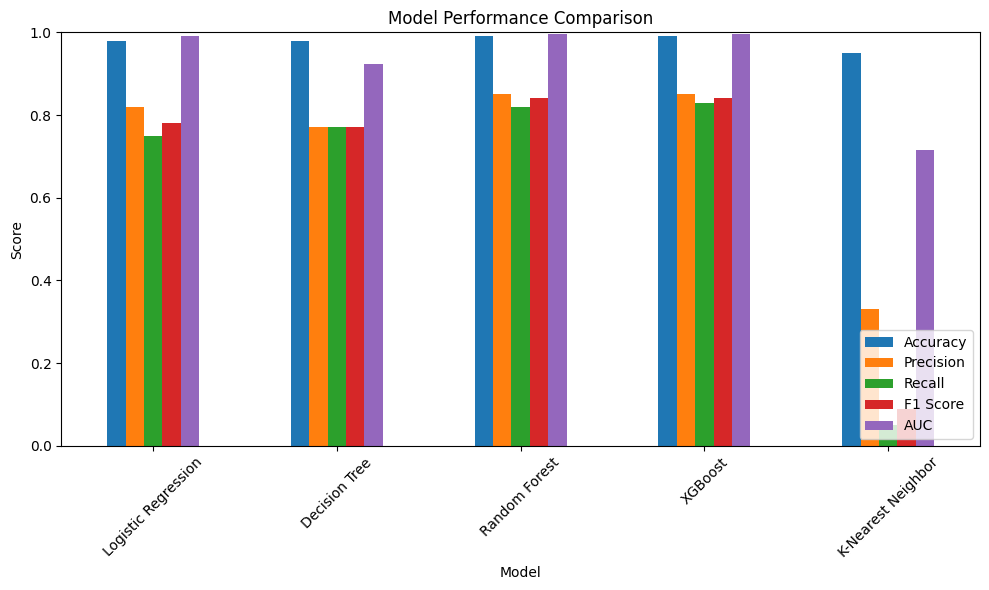

In [36]:
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'K-Nearest Neighbor'],
    'Accuracy': [0.98,0.98,0.99,0.99,0.95],
    'Precision': [0.82, 0.77,0.85,0.85,0.33],
    'Recall': [0.75, 0.77,0.82,0.83,0.05],
    'F1 Score': [0.78, 0.77,0.84,0.84,0.09],
    'AUC':[0.992044,0.922323,0.996163,0.996069,0.714956]
}

df = pd.DataFrame(results)

# Display comparison table
print(df)

# Plot comparison
df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [37]:
import pickle as pk

In [38]:
with open("label_encoder.pkl","wb") as file:
    pk.dump(label_encoder,file)

In [39]:
with open("logistic_regression.pkl","wb") as file:
    pk.dump(logistic_regressor,file)

In [40]:
with open("decision_tree.pkl","wb") as file:
    pk.dump(DT_classifier,file)

In [41]:
with open("random_forest.pkl","wb") as file:
    pk.dump(RF_classifier,file)

In [42]:
with open("xgb_classifier.pkl","wb") as file:
    pk.dump(xgb_classifier,file)

In [43]:
with open("KN_classifier.pkl","wb") as file:
    pk.dump(KN_classifier,file)